# 🧮 Phần 1: Lý Thuyết và Cài Đặt Thuật Toán (OLS, Ridge, Lasso, Cross-Validation)

Notebook này trình bày lý thuyết toán học và code Python minh họa các tính chất của OLS, Regularization (Ridge & Lasso), Cross-Validation và kiểm chứng định lý Gauss-Markov thông qua mô phỏng Monte Carlo.

## 1. Cài đặt các hàm toán học cốt lõi & OLS

Chúng ta sẽ nhập các hàm OLS cơ bản từ `part1/ols_implementation.py` và kiểm tra các tính chất của ma trận chiếu Hat Matrix:
- Đối xứng: $H^T = H$
- Lũy đẳng: $H^2 = H$

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd())))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from part1.ols_implementation import ols_fit, hat_matrix, model_metrics, coef_inference
from part1.ridge_lasso import ridge_fit, lasso_fit, vif, predict, rss
from part1.cross_validation import kfold_cv, find_best_lambda

# 1. Tạo dữ liệu giả lập đơn giản
np.random.seed(42)
n, p = 10, 2
X = np.column_stack([np.ones(n), np.random.randn(n, p)])
y = X @ np.array([2.0, 1.5, -1.0]) + np.random.randn(n) * 0.1

# 2. Kiểm tra Hat Matrix
H = hat_matrix(X)
print("Hat Matrix Shape:", H.shape)
print("1. Tính đối xứng (H.T ≈ H)? ->", np.allclose(H.T, H, atol=1e-8))
print("2. Tính lũy đẳng (H @ H ≈ H)? ->", np.allclose(H @ H, H, atol=1e-8))

# 3. Huấn luyện OLS và suy diễn thống kê
beta_hat, sigma_squared = ols_fit(X, y)
metrics = model_metrics(y, X @ beta_hat, X.shape[1])
inference_df = coef_inference(X, y, beta_hat, sigma_squared)

print("\n--- Chỉ số OLS Model ---")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

print("\n--- Bảng suy diễn Hệ số hồi quy OLS ---")
print(inference_df)

Hat Matrix Shape: (10, 10)
1. Tính đối xứng (H.T ≈ H)? -> True
2. Tính lũy đẳng (H @ H ≈ H)? -> True

--- Chỉ số OLS Model ---
RSS: 0.054481
TSS: 17.278419
R2: 0.996847
adjusted_R2: 0.995946
F_statistic: 1106.510301

--- Bảng Suy Diễn Hệ Số Hồi Quy OLS ---
   coefficient  std_error     t_stat       p_value  ci_lower  ci_upper
0     1.974111   0.028591  69.047209  3.513745e-11  1.906505  2.041718
1     1.472975   0.033330  44.193817  7.932508e-10  1.394162  1.551788
2    -0.991843   0.031259 -31.729941  7.982299e-09 -1.065759 -0.917928


## 2. Co rút hệ số (Ridge Trace)

Chúng ta sẽ thực hiện huấn luyện mô hình Ridge với các giá trị $\lambda$ khác nhau để xem hệ số co rút về phía 0 như thế nào (không chuẩn hóa hệ số chặn).

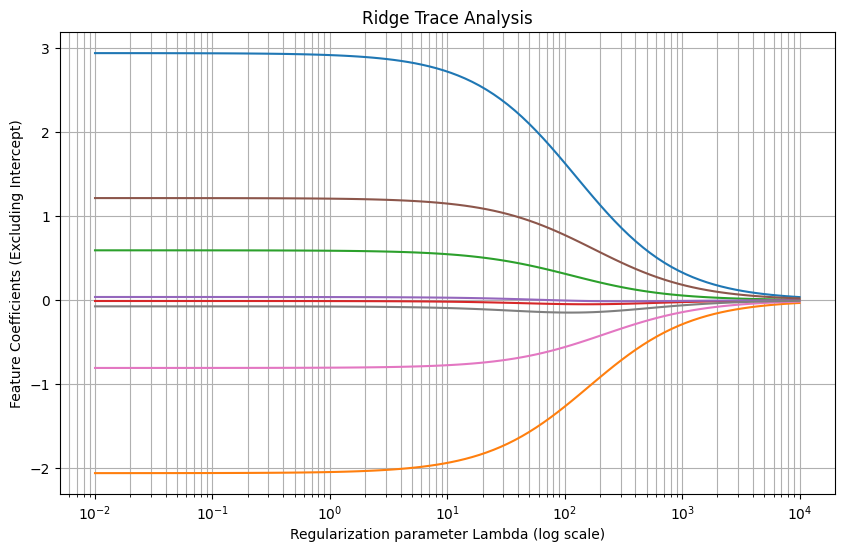

In [4]:
np.random.seed(42)
n, p = 150, 8
X_sim = np.random.randn(n, p)
X_sim_bias = np.column_stack([np.ones(n), X_sim])
true_beta = np.array([5.0, 3.0, -2.0, 0.5, 0.0, 0.0, 1.2, -0.8, 0.0])
y_sim = X_sim_bias @ true_beta + np.random.randn(n) * 0.5

# Tính hệ số Ridge với danh sách các lambda khác nhau
lambdas = np.logspace(-2, 4, 100)
coefs = []
for lam in lambdas:
    beta = ridge_fit(X_sim_bias, y_sim, lam=lam)
    coefs.append(beta[1:]) # Bỏ qua intercept

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, coefs)
plt.xscale('log')
plt.xlabel('Regularization parameter Lambda (log scale)')
plt.ylabel('Feature Coefficients (Excluding Intercept)')
plt.title('Ridge Trace Analysis')
plt.grid(True, which="both", ls="-")
plt.show()

## 3. Mô phỏng Monte Carlo kiểm chứng định lý Gauss-Markov

Định lý Gauss-Markov chỉ ra rằng trong lớp các ước lượng tuyến tính không chệch của $\beta$, ước lượng OLS có phương sai nhỏ nhất (BLUE - Best Linear Unbiased Estimator).

Chúng ta chạy mô phỏng Monte Carlo bằng cách sinh $M=2000$ mẫu ngẫu nhiên từ quá trình: 
$$y = X \beta + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2 I)$$

và chứng minh thực nghiệm:
1. Ước lượng OLS $\hat{\beta}$ là không chệch: $\mathbb{E}[\hat{\beta}] = \beta$.
2. Phân phối của $\hat{\beta}$ tuân thủ chính xác lý thuyết phân phối chuẩn.


--- Bảng Tổng Hợp Kết Quả Monte Carlo ---
   true_beta  mean_beta_hat      bias
0        2.0       1.995791 -0.004209
1        1.5       1.502704  0.002704
2       -1.0      -1.000135 -0.000135


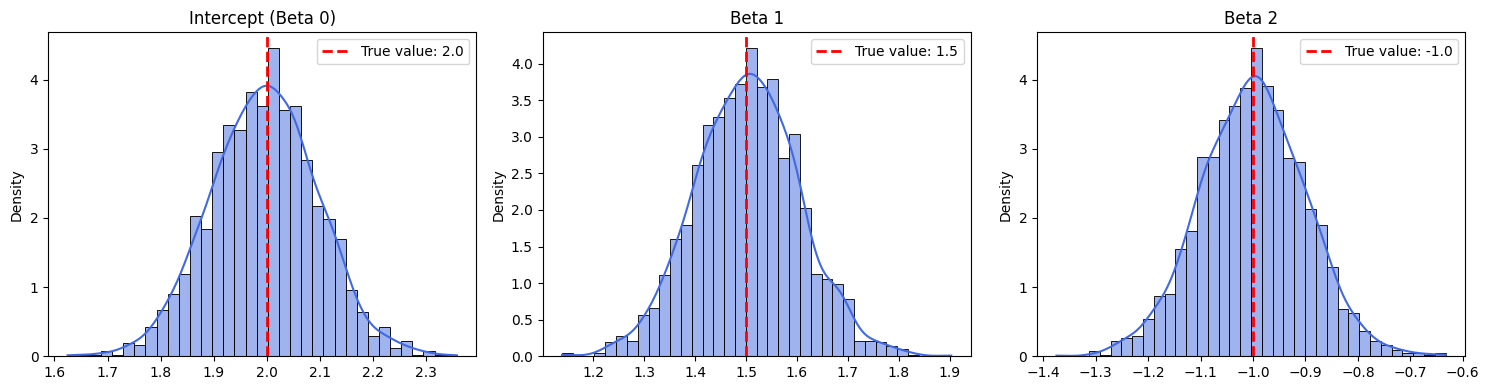

In [3]:
from part1.residual_analysis import monte_carlo_gauss_markov

# Thiết lập tham số giả lập
n_simulations = 2000
n_samples = 100
true_beta_mc = np.array([2.0, 1.5, -1.0])

# Chạy mô phỏng
mc_results = monte_carlo_gauss_markov(n_simulations, n_samples, true_beta_mc)
summary = mc_results["summary"]
beta_hats = mc_results["beta_hats"]

print("\n--- Bảng Tổng Hợp Kết Quả Monte Carlo ---")
print(summary)

# Vẽ phân phối của hệ số beta_hat
plt.figure(figsize=(15, 4))
labels = ['Intercept (Beta 0)', 'Beta 1', 'Beta 2']
for i in range(beta_hats.shape[1]):
    plt.subplot(1, 3, i+1)
    sns.histplot(beta_hats[:, i], kde=True, color='royalblue', stat='density')
    plt.axvline(x=true_beta_mc[i], color='red', linestyle='--', linewidth=2, label=f'True value: {true_beta_mc[i]}')
    plt.title(labels[i])
    plt.legend()
plt.tight_layout()
plt.show()